# LeRobotVideoDataset example

Loads `LSY-lab/stack_without_ft_tact_v4` — a LeRobot v2.1 dataset whose camera
streams are external AV1-encoded mp4 files — via the `repo_id=` origin. Only
the two requested episodes are fetched; the other 49 are never downloaded.


In [ ]:
from robotdataset import LeRobotVideoDataset, batchViz

## Load two episodes

`delta_timestamps` requests a 3-frame history (0.6s, 0.3s and 0.0s back) for the
primary camera; every other modality defaults to the anchor step only.

In [ ]:
dataset = LeRobotVideoDataset(
    repo_id="LSY-lab/stack_without_ft_tact_v4",
    episodes=[0, 1],
    batch_size=4,
    delta_timestamps={"observation/images/primary": [-0.6, -0.3, 0.0]},
)

print("num_episodes:", dataset.num_episodes)
print("total steps:", len(dataset))
print("fps:", dataset.fps)

## Inspect the inferred modalities

In [ ]:
for path, spec in sorted(dataset.get_modalities().items()):
    print(f"{path:35s} {spec['kind']:8s} {spec['shape']}")

## Sample a batch

Images come back channel-first (`B, T, C, H, W`) — the on-disk storage is HWC,
permuted automatically because `observation/images/*` is in `dataset.image_keys`.

In [ ]:
batch = dataset.sample()

for key in ("observation/images/primary", "observation/images/wrist",
            "observation/state/cartesian", "action"):
    print(f"{key:35s} {tuple(batch[key].shape)}")

## Visualize the sampled window

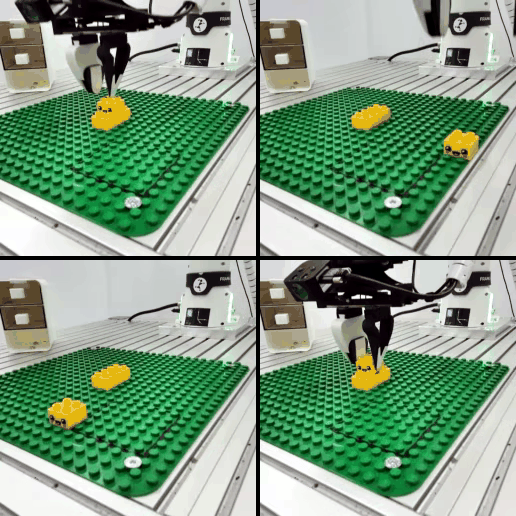

In [6]:
batchViz(batch, key="observation/images/primary", fps=4)